1.	Data Cleaning and Preparation:

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [20]:
# 1.Loading the dataset
df=pd.read_csv("Cardiotocographic.csv") 

In [4]:
df.info() # getting the basic information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
df.head() # Preview of dataset 

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [7]:
df.shape # understanding the number of rows and columns

(2126, 14)

In [ ]:
# 2. Handling missing values appropriately 

In [8]:
# Checking for  missing values
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [9]:
# Replacing Numerical columns missing values with mean
num_cols = df.select_dtypes(include=['float64','int64']).columns # selecting numerical columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())# Numerical → replace with mean

In [10]:
df.isnull().sum() # shows missing values removed

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [18]:
# 3. Fix inconsistent data types
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
else:
  pass

print("\n===== Data Types After Cleaning =====")
print(df.dtypes)


===== Data Types After Cleaning =====
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [21]:
# Checking for duplicates
df.duplicated().sum()

np.int64(2)

In [22]:
# seeing the duplicate values
df[df.duplicated()]

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
1115,122.0,0.000000,0.0,0.000000,0.0,0.0,0.0,19.0,1.9,0.0,15.1,39.0,0.0,1.0
1458,148.0,0.004717,0.0,0.002358,0.0,0.0,0.0,40.0,0.9,0.0,10.6,35.0,0.0,1.0


In [25]:
# droping the duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum() # shows duplicated values are removed

np.int64(0)

In [ ]:
# 4. ●	Detect and treat outliers if necessary.

<Axes: >

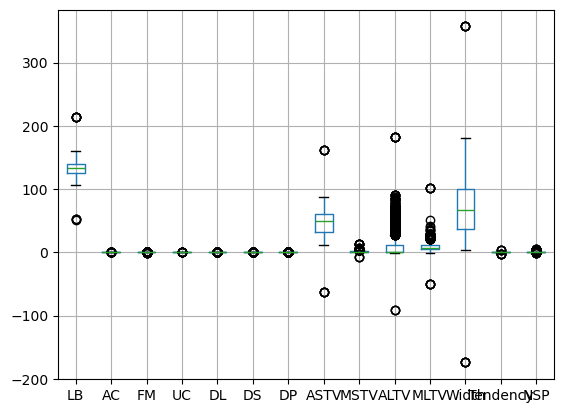

In [26]:
# checking for outliers
df.boxplot()

In [27]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

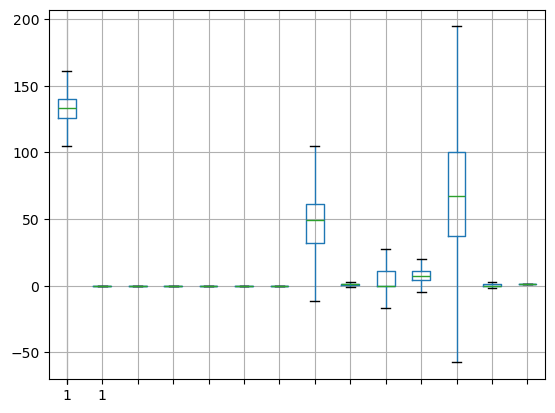

In [31]:
plt.boxplot(df[col])
plt.show() # shows outliers are treated

2.	Statistical Summary:

In [ ]:
# 	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).

In [34]:
num_df= df.select_dtypes(include=('float64','int64')) # selecting numerical datatypes
# Statistical summary
Summary=pd.DataFrame({
    "Mean":num_df.mean(),
    "Median":num_df.median(),
    "Std_dev":num_df.std(),
    "Min":num_df.min(),
    "Max":num_df.max(),
    "IQR": num_df.quantile(0.75) - num_df.quantile(0.25)})
print(Summary)

                Mean      Median    Std_dev         Min         Max        IQR
LB        133.291604  133.000000   9.976211  105.000000  161.000000  14.000000
AC          0.003149    0.001634   0.003851   -0.008475    0.014124   0.005650
FM          0.001570    0.000000   0.002487   -0.003853    0.006421   0.002568
UC          0.004365    0.004486   0.003001   -0.005158    0.013552   0.004678
DL          0.001772    0.000000   0.002670   -0.004938    0.008230   0.003292
DS          0.000000    0.000000   0.000000    0.000000    0.000000   0.000000
DP          0.000000    0.000000   0.000000    0.000000    0.000000   0.000000
ASTV       46.998334   49.000000  17.609911  -11.500000  104.500000  29.000000
MSTV        1.304554    1.200000   0.781303   -0.800000    3.200000   1.000000
ALTV        6.697979    0.000000  10.381254  -16.500000   27.500000  11.000000
MLTV        8.017610    7.400000   5.094192   -4.850000   20.350000   6.300000
Width      70.351685   67.486468  39.773195  -57.500

3.	Data Visualization:

In [ ]:
 # ●	Create histograms or boxplots to visualize the distributions of various numerical variables.

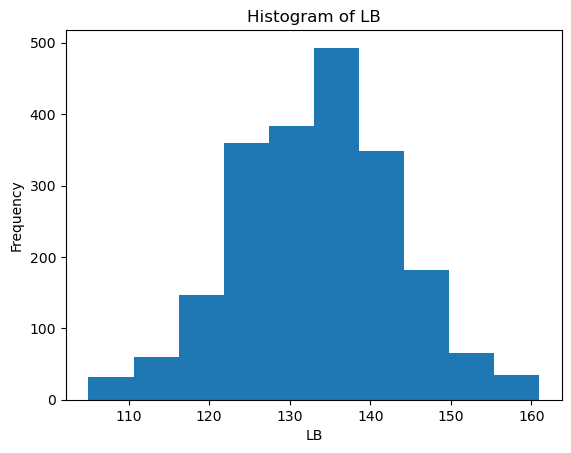

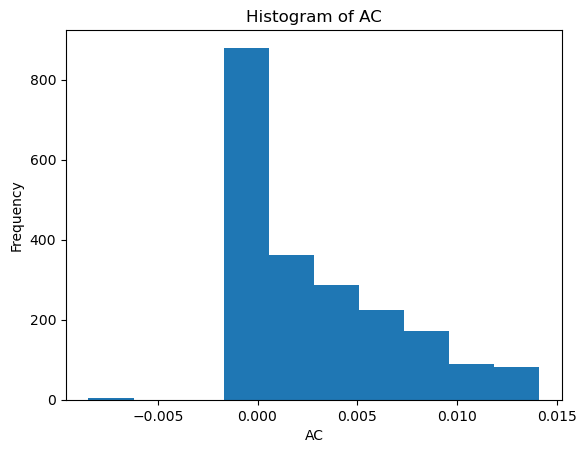

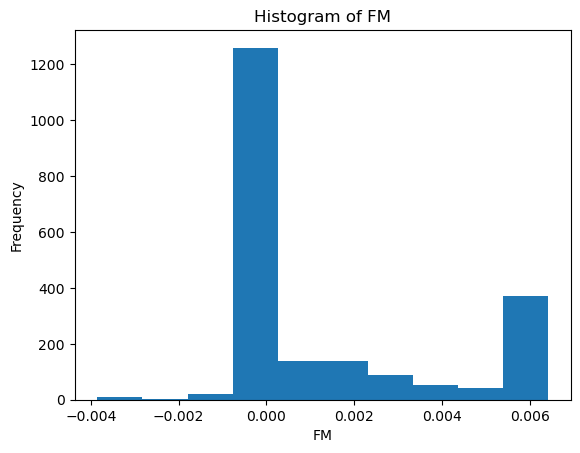

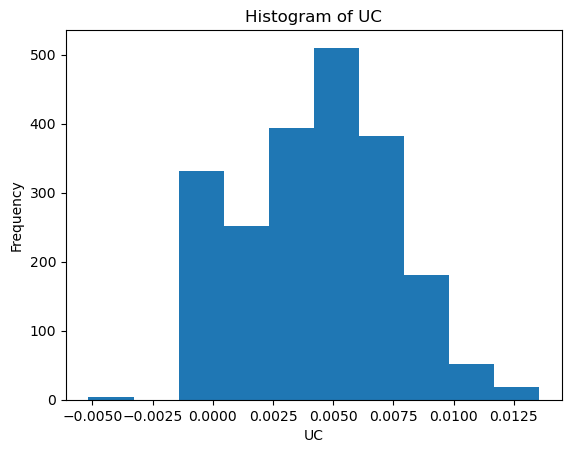

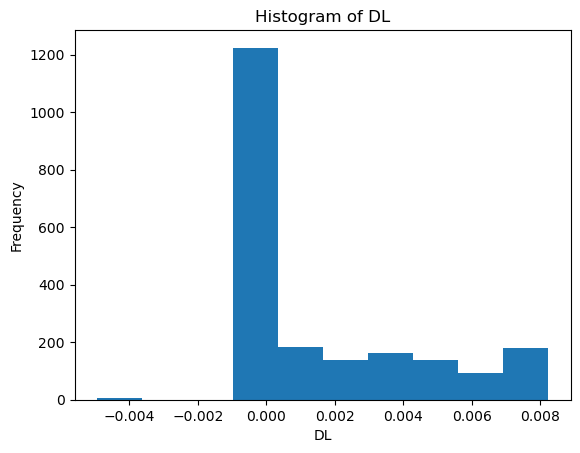

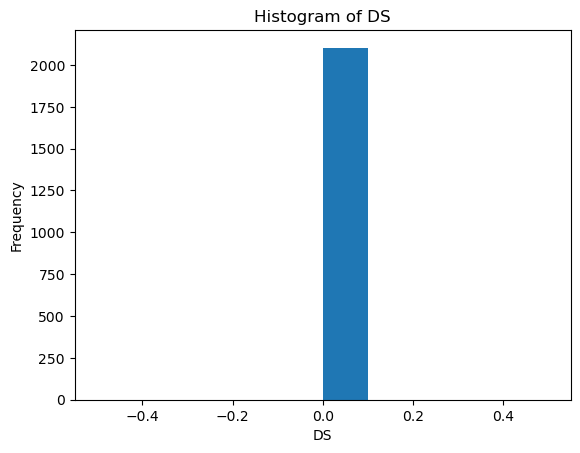

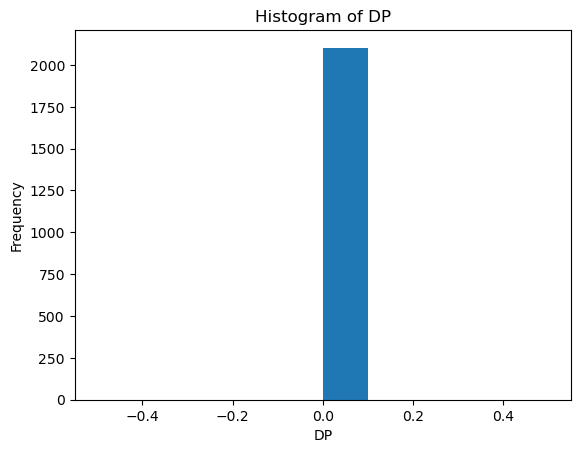

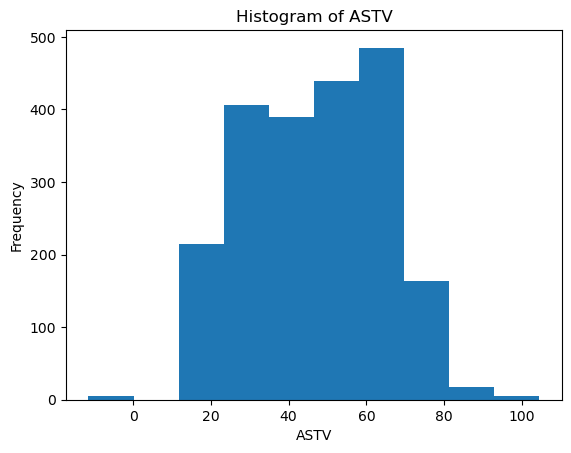

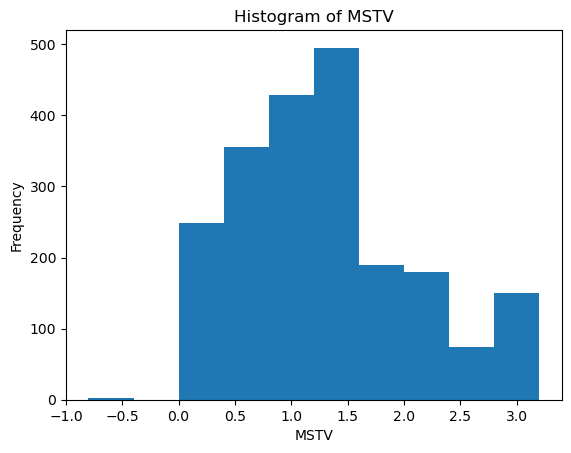

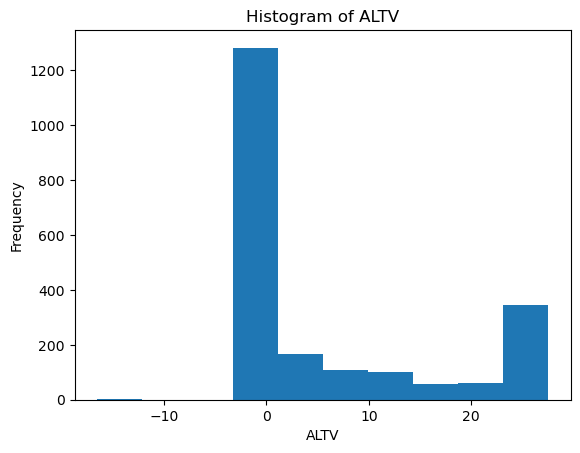

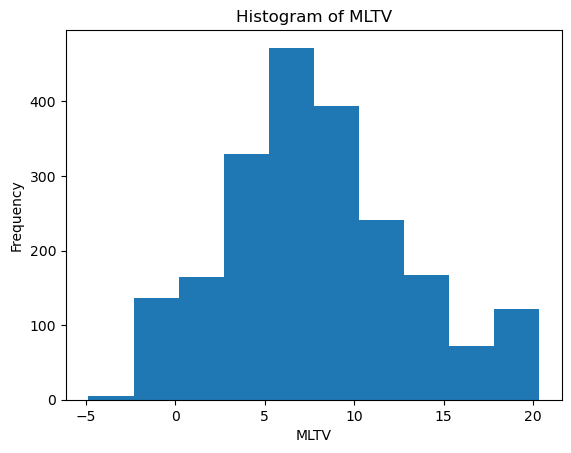

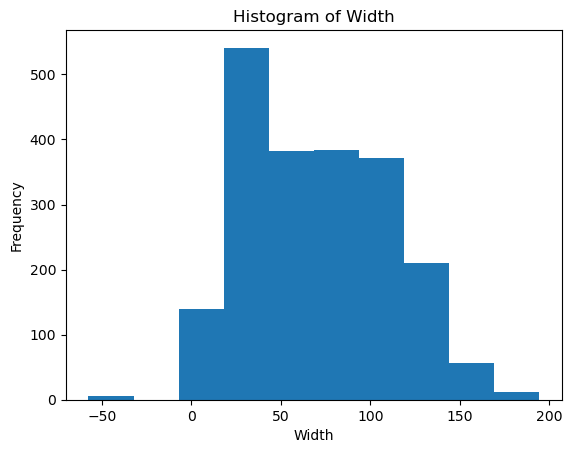

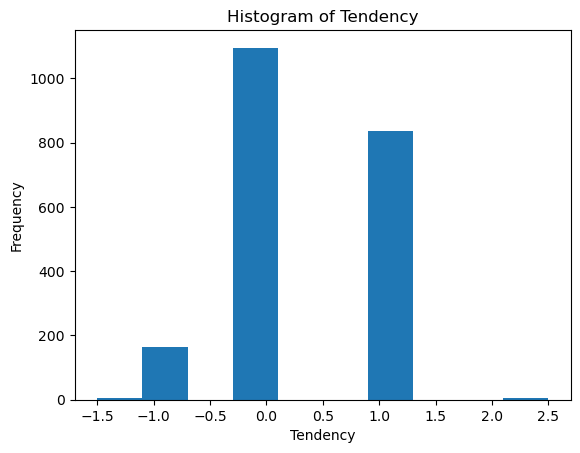

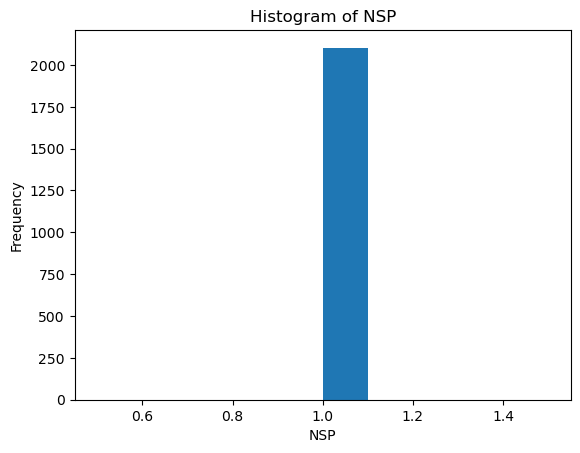

In [36]:
# Histogram
for col in num_df.columns:
    plt.figure()
    plt.hist(num_df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

In [37]:
# ●	Use bar charts or pie charts to display the frequency of categories for categorical variables.

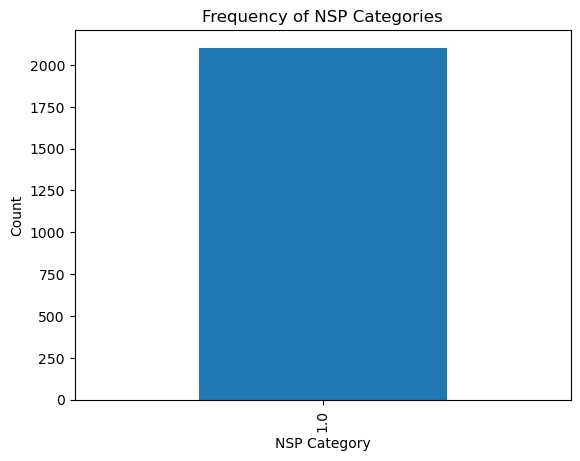

In [52]:
# Bar chart 
plt.figure()
df["NSP"].value_counts().sort_index().plot(kind="bar")
plt.title("Frequency of NSP Categories")
plt.xlabel("NSP Category")
plt.ylabel("Count")
plt.show()

In [ ]:
# ●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

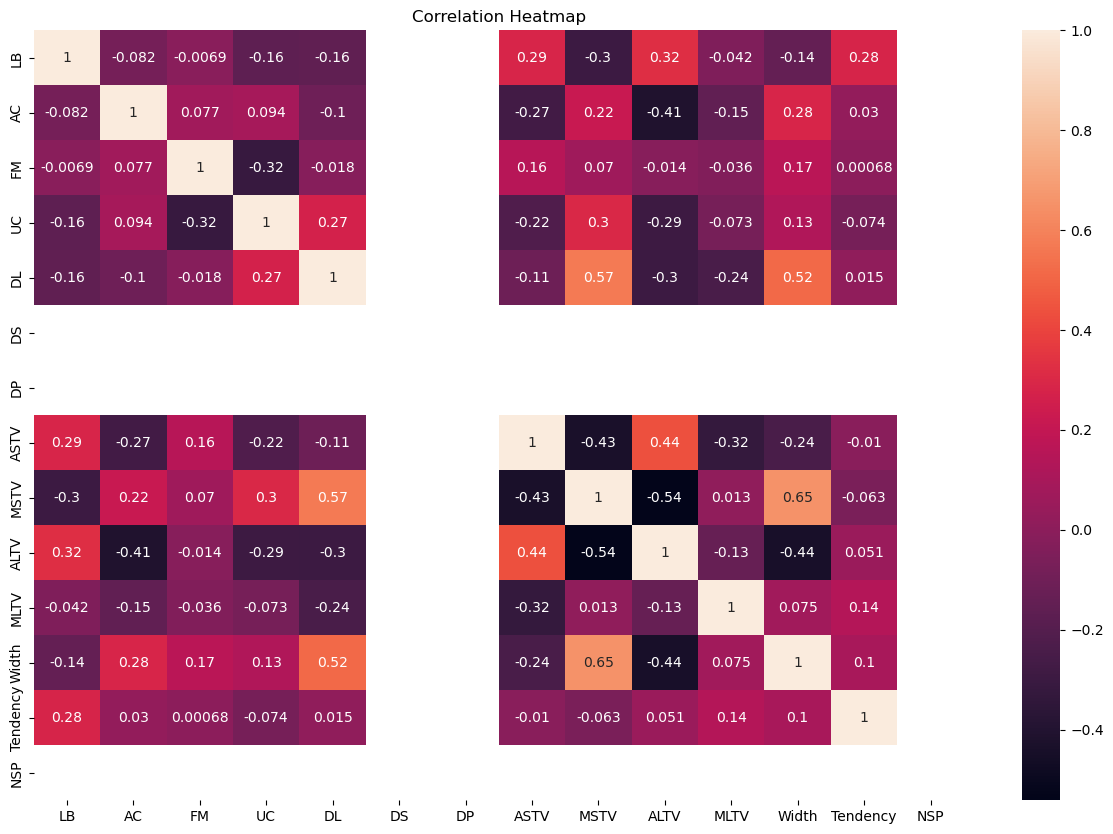

                LB        AC        FM        UC        DL  DS  DP      ASTV  \
LB        1.000000 -0.081715 -0.006859 -0.163765 -0.156858 NaN NaN  0.286501   
AC       -0.081715  1.000000  0.076600  0.093536 -0.103370 NaN NaN -0.273942   
FM       -0.006859  0.076600  1.000000 -0.318156 -0.018024 NaN NaN  0.155798   
UC       -0.163765  0.093536 -0.318156  1.000000  0.268151 NaN NaN -0.217484   
DL       -0.156858 -0.103370 -0.018024  0.268151  1.000000 NaN NaN -0.112289   
DS             NaN       NaN       NaN       NaN       NaN NaN NaN       NaN   
DP             NaN       NaN       NaN       NaN       NaN NaN NaN       NaN   
ASTV      0.286501 -0.273942  0.155798 -0.217484 -0.112289 NaN NaN  1.000000   
MSTV     -0.297040  0.219101  0.070412  0.298462  0.566625 NaN NaN -0.433731   
ALTV      0.323777 -0.410713 -0.013820 -0.294226 -0.296383 NaN NaN  0.438800   
MLTV     -0.041651 -0.151983 -0.036405 -0.072768 -0.242131 NaN NaN -0.324869   
Width    -0.140008  0.284221  0.165220  

In [59]:
# Correlation heatmaps
plt.figure(figsize=(15,10))
corr = df.corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()
print(corr)

In [ ]:
#●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

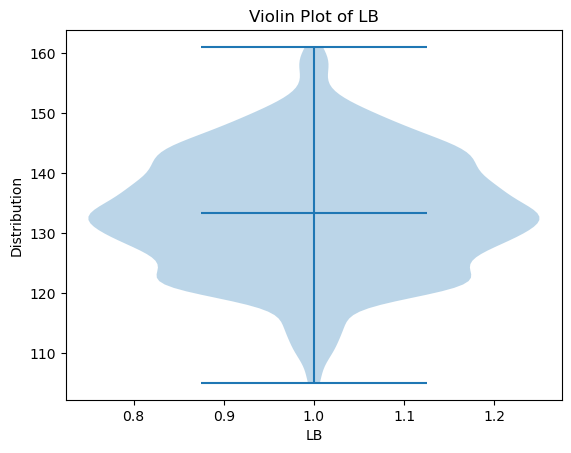

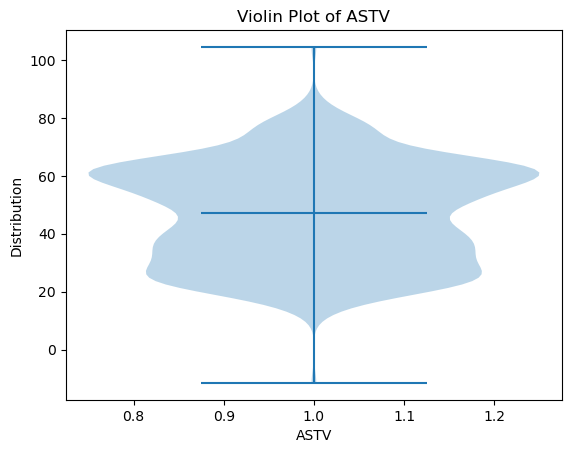

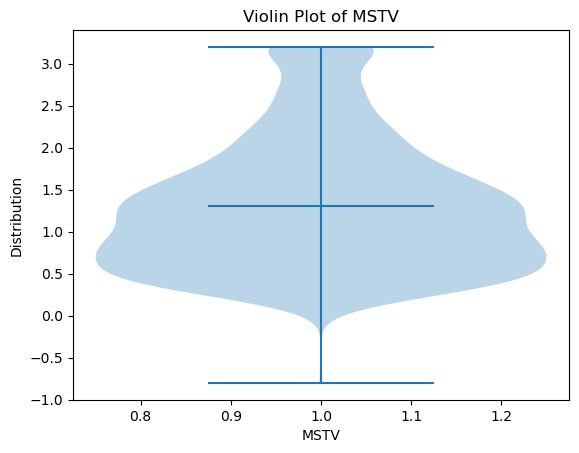

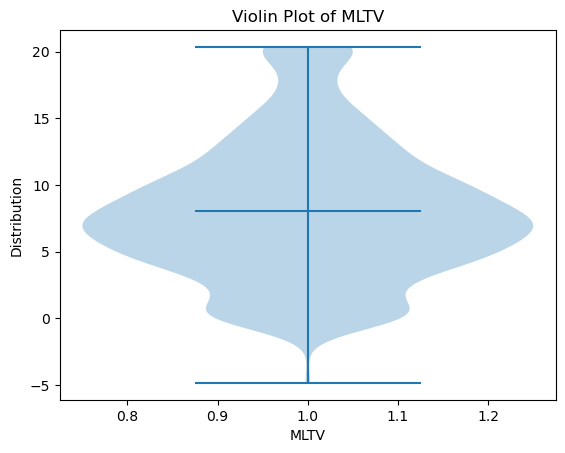

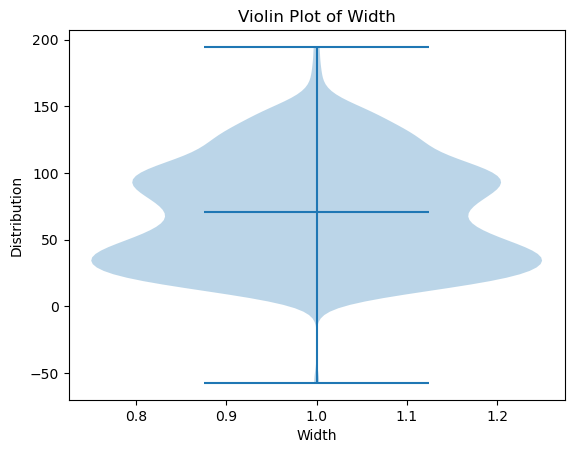

In [51]:
# Violin plots
variables = ["LB", "ASTV", "MSTV", "MLTV", "Width"]

# Create violin plots
for var in variables:
    plt.figure()
    plt.violinplot(df[var].dropna(), showmeans=True)
    plt.title(f"Violin Plot of {var}")
    plt.xlabel(var)
    plt.ylabel("Distribution")
    plt.show()

In [ ]:
# ●	Identify any correlations between variables and discuss their potential implications.

In [ ]:
# ●	Summarize the key insights and patterns discovered through your exploratory analysis.


In [ ]:
# ●	Discuss how these findings could impact decision-making or further analyses.

In [ ]:
Variables such as fetal heart rate variability (MSTV, MLTV), accelerations (AC), and decelerations (DL, DP) provide stronger indicators of fetal distress than baseline FHR alone, enabling earlier and more accurate clinical interventions.